In [687]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import psycopg2

db_name = "park"

def execute_query(query, *args):
    conn = psycopg2.connect(
        dbname=f"{db_name}",
        user="postgres",
        password="pgpass",
        host="localhost",
        port=5432
    )

    cur = conn.cursor()
    cur.execute(query, *args)
    try:
        result = cur.fetchall()
    except psycopg2.ProgrammingError:
        result = None
    conn.commit()
    conn.close()
    return result

def execute_query_many(query, *args):
    conn = psycopg2.connect(
        dbname=f"{db_name}",
        user="postgres",
        password="pgpass",
        host="localhost",
        port=5432
    )

    cur = conn.cursor()
    cur.executemany(query, *args)
    try:
        result = cur.fetchall()
    except psycopg2.ProgrammingError:
        result = None
    conn.commit()
    conn.close()
    return result

Let's start by looking at the performance of the park when no optimizations are applied vs when the Bayesian optimizer is applied. 

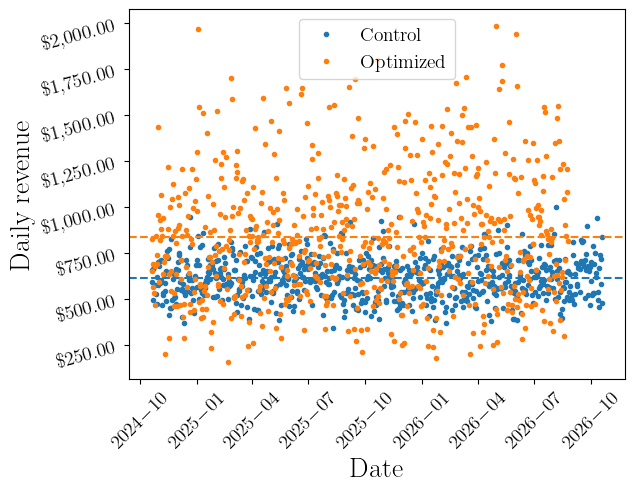

615.9958960328318 836.9911111111111


In [1042]:
from matplotlib.ticker import FuncFormatter

dates, revenue = zip(*execute_query("SELECT date, SUM(total_revenue) FROM attr_summary_old GROUP BY date ORDER BY date;"))
revenue = np.array(revenue).astype(float)

line, = plt.plot(dates, revenue, marker='.', linestyle='None', label="Control")
r1 = np.mean(revenue)
plt.axhline(r1, color=line.get_color(), linestyle='--')

dates, revenue = zip(*execute_query("SELECT date, SUM(total_revenue) FROM attr_summary GROUP BY date ORDER BY date;"))
revenue = np.array(revenue).astype(float)
line, = plt.plot(dates, revenue, marker='.', linestyle='None', label="Optimized")
r2 = np.mean(revenue)
plt.axhline(r2, color=line.get_color(), linestyle='--')

formatter = FuncFormatter(lambda y, _: f'\\${y:,.2f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylabel("Daily revenue", fontsize=20)
plt.yticks(rotation=15, fontsize=14)

plt.xlabel("Date", fontsize=20)
plt.xticks(rotation=45, fontsize=14)

plt.legend(fontsize=14)
plt.show()
print(r1, r2)

Looks good! The optimizer is clearly finding some inefficiencies in the park; the revenue increase by $100/day, or roughly 30%, on average. It seems like most of this improvement happens in the first few days of the simulation. Let's take a look at what kind of optimizations it's making. We can start by looking at how the different guest wealth levels are affected by the optimization. Let's analyze the average number of transactions in the park for each wealth level.

/var/folders/sc/8v0fl80x7h1_jksj8381ftgw0000gn/T/ipykernel_94569/1319913122.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels=axs[1].get_xticks(), rotation=45)


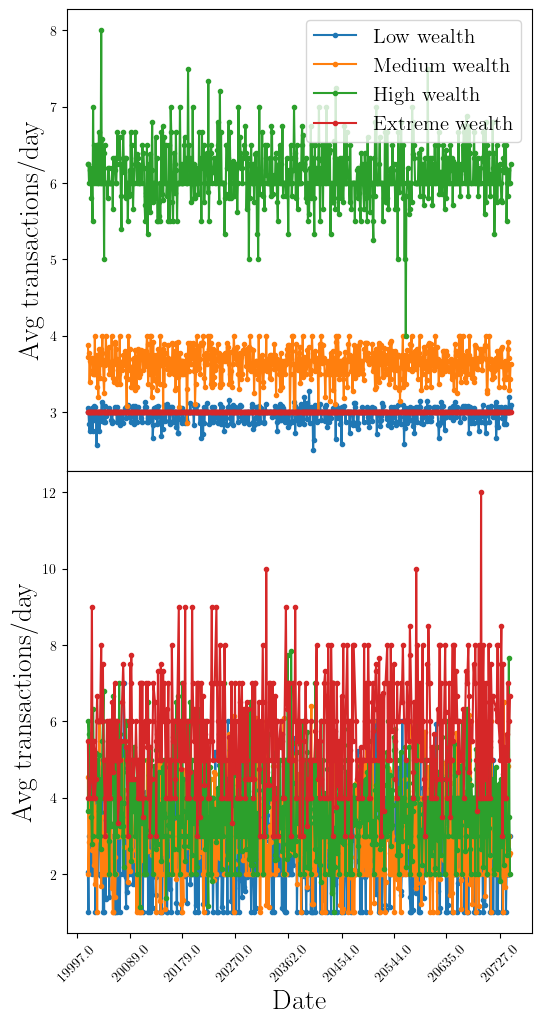

In [1043]:
def plot_number_transactions(ax, table):
    transactions = execute_query(f"""
        SELECT
            DATE(t.time) AS day,
            g.wealth,
            COUNT(t.id)::float / COUNT(DISTINCT g.id) AS avg_transactions_per_guest
        FROM {table} AS t
        JOIN guests AS g ON t.guest_id = g.id
        GROUP BY DATE(t.time), g.wealth
        ORDER BY
            CASE g.wealth
                WHEN 'low' THEN 1
                WHEN 'medium' THEN 2
                WHEN 'high' THEN 3
                WHEN 'extreme' THEN 4
            END,
            day;
    """)

    data = defaultdict(lambda: {'day': [], 'avg': []})
    for day, wealth, avg in transactions:
        data[wealth]['day'].append(day)
        data[wealth]['avg'].append(avg)

    wealth_order = ['low', 'medium', 'high', 'extreme']

    for wealth in wealth_order:
        ax.plot(data[wealth]['day'], data[wealth]['avg'], label=f'{wealth.capitalize()} wealth', marker='.')


fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(6, 12))
plot_number_transactions(axs[0], "transactions_old")
plot_number_transactions(axs[1], "transactions")

axs[0].legend(fontsize=15)
#axs[0].set_ylim(0.0, 20)
#axs[1].set_ylim(0.0, 20)
axs[1].set_xlabel("Date", fontsize=20)
axs[0].set_ylabel("Avg transactions/day", fontsize=20)
axs[1].set_ylabel("Avg transactions/day", fontsize=20)
axs[1].set_xticklabels(labels=axs[1].get_xticks(), rotation=45)
plt.subplots_adjust(hspace=0, wspace=0)
plt.show()

It looks like the extremely wealthy guests were not able to find any interesting rides for the initial conditions, so would immediately leave the park. After optimization, the wealthy guests are now able to attend a few rides before their dissatisfaction rises too far and they leave. Now, let's look at the paths the different wealth levels are taking through the park.

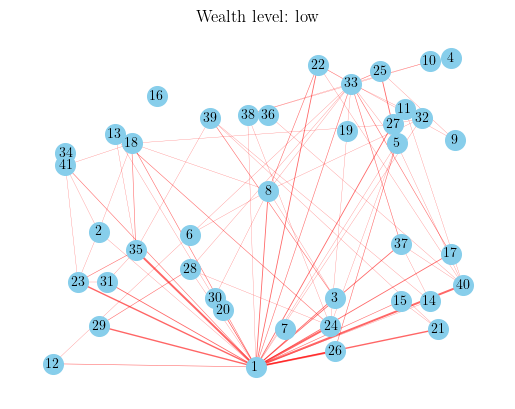

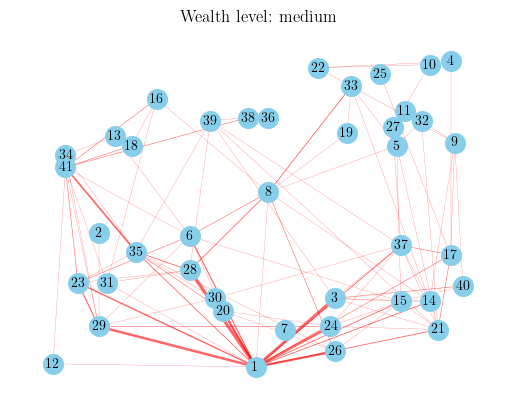

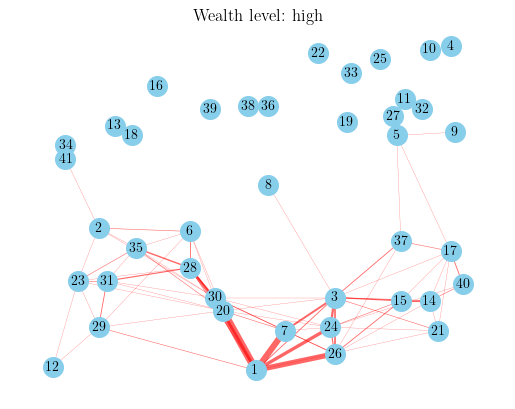

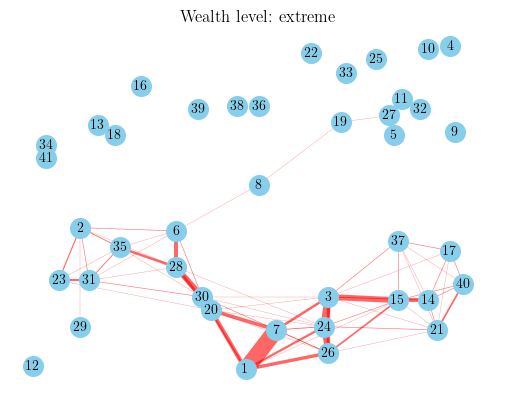

In [1044]:
def create_park_graph():
    result = execute_query("SELECT id, name, duration, cost, xpos, ypos from attractions;")

    graph = nx.DiGraph()

    for n, (id, name, duration, cost, x, y) in enumerate(result):
        dt = 0.0 if (name == "Entrance") else duration.total_seconds() / (8 * 3600) # Convert to a float representing a fraction of the working day
        graph.add_node(id, pos=np.array([float(x), float(y)]), name=name, cost=float(cost), duration=dt)
    
    for i in range(len(result)):
        id1, _, _, _, x1, y1 = result[i]
        for j in range(len(result)):
            if i == j:
                continue
            id2, _, _, _, x2, y2 = result[j]
            distance = np.sqrt(float(x1 - x2)**2 + float(y1 - y2)**2)
            graph.add_edge(id1, id2, weight=distance)
    
    return graph

park_graph = create_park_graph()

def plot_transitions(wealth, table):
    start_date = '2026-01-01'
    end_date = '2026-12-30'

    transactions = execute_query(f"""
        WITH filtered AS (
            SELECT
                t.id,
                t.guest_id,
                t.attr_id,
                g.wealth,
                DATE(t.time) AS day,
                t.amount,
                t.time AS time
            FROM {table} AS t
            JOIN guests AS g ON t.guest_id = g.id
            WHERE g.wealth = %s
            AND t.time BETWEEN %s AND %s
        ),
        distinct_histories AS (
            SELECT DISTINCT guest_id, day FROM filtered
        ),
        random_histories AS (
            SELECT guest_id, day
            FROM distinct_histories
            ORDER BY RANDOM()
            LIMIT 100
        )
        SELECT f.id, f.guest_id, f.attr_id, f.wealth, f.amount, f.time
        FROM filtered AS f
        JOIN random_histories AS r
        ON f.guest_id = r.guest_id AND f.day = r.day
        ORDER BY f.guest_id, f.day, f.time;
        """, (wealth, start_date, end_date))

    histories = defaultdict(list)

    for tx_id, guest_id, attr_id, wealth, amount, time in transactions:
        if amount is None:
            amount = 0.0

        day = time.date()

        histories[(guest_id, day)].append({
            "guest_id": guest_id,
            "id": attr_id,
            "wealth": wealth,
            "amount": float(amount),
            "time": time
        })

    # Sort each guest/day’s transactions chronologically
    for key in histories:
        histories[key].sort(key=lambda x: x["time"])

    ids, = zip(*execute_query("SELECT id FROM attractions;"))
    adjacency = {i: {j: 0 for j in ids} for i in ids}

    for _,transactions in histories.items():
        for i in range(len(transactions) - 1):
            item1 = transactions[i]
            item2 = transactions[i+1]

            id1 = item1['id']
            id2 = item2['id']

            adjacency[id1][id2] += 1

    park_graph = create_park_graph()
    ids = nx.get_node_attributes(park_graph, "id")
    positions = nx.get_node_attributes(park_graph, "pos")

    g = nx.Graph()

    for node_id in adjacency.keys():
        g.add_node(node_id, pos=positions[node_id])

    for i in adjacency:
        for j in adjacency[i]:
            if adjacency[i][j] > 0:
                g.add_edge(i, j, weight=adjacency[i][j])

    pos = nx.get_node_attributes(g, 'pos')
    nx.draw_networkx_nodes(g, pos, node_size=200, node_color='skyblue')

    weights = [g[u][v]['weight'] for u, v in g.edges()]

    nx.draw_networkx_edges(g, pos, width=[w*0.2 for w in weights], alpha=0.6, edge_color='red')

    nx.draw_networkx_labels(g, pos, font_size=10, font_color='black')

    plt.axis('off')

for wealth in ["low", "medium", "high", "extreme"]:
    plot_transitions(wealth, "transactions")
    plt.title(f"Wealth level: {wealth}")
    plt.show()


We can see that the different wealth levels are exploring slightly different regions of the park. 